<a href="https://colab.research.google.com/github/bcorrad/frustum_pointnets_pytorch/blob/master/Frustum_Pointnets_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Frustum PointNet Demo

In [ ]:
# Install needed packages
!pip install torch torchvision numpy scikit-learn matplotlib tqdm
!pip install opencv-python pillow ipdb mayavi configobj

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 67.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached vtk-9.4.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 13.3 MB/s eta 0:00:00
Using cached vtk-9.4.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (105.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.6 MB/s eta 0:00:00
  Created wheel for mayavi: filename=mayavi-4.8.2-cp310-cp310-linux_x86_64.whl size=17568778 sha256=e06c8a87324d494ccd0761

In [ ]:
# Clone the Pytorch implementation of Frustum Pointnets repo
# !git clone https://github.com/simon3dv/frustum_pointnets_pytorch.git
!git clone https://github.com/bcorrad/frustum_pointnets_pytorch.git
%cd frustum_pointnets_pytorch

Cloning into 'frustum_pointnets_pytorch'...
remote: Enumerating objects: 2298, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 2298 (delta 0), reused 3 (delta 0), pack-reused 2294 (from 1)
Receiving objects: 100% (2298/2298), 14.86 MiB | 15.02 MiB/s, done.
Resolving deltas: 100% (1619/1619), done.
/content/frustum_pointnets_pytorch


In [ ]:
# Build the folder structure to make the code work with KITTI
!mkdir -p /content/frustum_pointnets_pytorch/dataset/KITTI/object
!mkdir -p /content/frustum_pointnets_pytorch/dataset/KITTI/ImageSets
!rm -r dataset/KITTI

In [ ]:
# Download KITTI dataset samples (WARNING: this phase may need a long time)
import os
import requests
import zipfile
from tqdm import tqdm

def download_file(url, output_dir, filename):
    """
    Downloads from url and saves it in output_dir with filename.
    """
    print(f"Creating work directories: {output_dir}")
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, filename)
    print(f"File {filename} verrà salvato in {file_path}.")

    if os.path.exists(file_path):
        print(f"File {filename} already exists in {output_dir}: {file_path}")
        return file_path
    else:
        print(f"File {filename} already exists in {output_dir}.")

    print(f"Downloading {filename} from {url}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(file_path, "wb") as file:
            # Print total size of file
            total_size = int(response.headers.get("content-length", 0))
            print(f"File size: {total_size / (1024 * 1024):.2f} MB")
            # Show progress bar
            progress_bar = tqdm(total=total_size, unit="B", unit_scale=True)
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
                progress_bar.update(len(chunk))
            progress_bar.close()
        print(f"File saved in {file_path}.")
    else:
        print(f"Error during download: {response.status_code}")
        return None

    return file_path

def extract_subset(file_path, extract_to, file_list, sub_dir):
    """
    Decompress only a specific subset of files from a ZIP archive.
    """
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        # If file_list is none, extract all the files in zip_ref
        if file_list is None:
          print(f"Extraction of all the files: {extract_to}")
          zip_ref.extractall(extract_to)
          return
        for file_name in file_list:
            full_path = os.path.join("training", sub_dir, file_name)
            # print(f"Verificare l'esistenza del file: {full_path}")
            # If full_path file already exists, skip
            print(f"Checking the existence of file: {full_path}, {os.path.join(extract_to, full_path)}")
            if os.path.exists(os.path.join(extract_to, full_path)):
                print(f"Il file {file_name} esiste già in {extract_to}: {os.path.join(extract_to, file_name)}")
                continue
            if full_path in zip_ref.namelist():
                zip_ref.extract(full_path, extract_to)
                print(f"Extraction completed: {file_name} in {extract_to}")
            else:
                print(f"File not found in the archive: {file_name}")

# URL of KITTI Dataset files
urls = {
    "calib": "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_calib.zip",
    "velodyne": "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_velodyne.zip",
    "image_2": "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip",
    "label_2": "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip",
}

# Output folder to same demo samples
output_directory = "dataset/KITTI/object"
subset_directory = os.path.join(output_directory)

# List of samples to be extracted (specify ids of samples if you want to use a subset of the dataset)
file_ids = ["000000", "000001", "000002", "000003", "000004", "000005", "000006", "000007", "000008", "000009"]
file_list = {
    "calib": [f"{file_id}.txt" for file_id in file_ids],
    "velodyne": [f"{file_id}.bin" for file_id in file_ids],
    "image_2": [f"{file_id}.png" for file_id in file_ids],
    "label_2": [f"{file_id}.txt" for file_id in file_ids],
}

use_subset_for_demo = True  # If True, only samples from file_ids list will be extracted; else, all the dataset samples will be extracted (huge memory required)

# Download and extract dataset samples
for component, url in urls.items():
    print(f"Downloading and extracting {component}...")
    zip_file = download_file(url, output_directory, f"{component}.zip")
    if zip_file:
        print(f"Extracting {component} into {subset_directory} from the file {zip_file}")
        if use_subset_for_demo:
            extract_subset(zip_file, subset_directory, file_list[component], f"{component}")
        else:
            extract_subset(zip_file, subset_directory, None, f"{component}")
    else:
        print(f"Error during the download or extraction of {component}.")


Scaricando ed estraendo calib...
Creazione cartelle di lavoro: dataset/KITTI/object
Il file calib.zip verrà salvato in dataset/KITTI/object/calib.zip.
Il file calib.zip non esiste in dataset/KITTI/object.
Scaricando calib.zip da https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_calib.zip...
File size: 25.61 MB


100%|██████████| 26.9M/26.9M [00:00<00:00, 108MB/s]


File salvato in dataset/KITTI/object/calib.zip.
Estrazione di calib in dataset/KITTI/object del file dataset/KITTI/object/calib.zip
Verificare l'esistenza del file: training/calib/000000.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/calib/000000.txt
Estrazione completata: 000000.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/calib/000001.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/calib/000001.txt
Estrazione completata: 000001.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/calib/000002.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/calib/000002.txt
Estrazione completata: 000002.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/calib/000003.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/calib/000003.txt
Estrazione completata: 000003.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/calib/000004.txt
Verificare l'esistenz

100%|██████████| 28.8G/28.8G [10:13<00:00, 46.8MB/s]


File salvato in dataset/KITTI/object/velodyne.zip.
Estrazione di velodyne in dataset/KITTI/object del file dataset/KITTI/object/velodyne.zip
Verificare l'esistenza del file: training/velodyne/000000.bin
Verificare l'esistenza del file: dataset/KITTI/object/training/velodyne/000000.bin
Estrazione completata: 000000.bin in dataset/KITTI/object
Verificare l'esistenza del file: training/velodyne/000001.bin
Verificare l'esistenza del file: dataset/KITTI/object/training/velodyne/000001.bin
Estrazione completata: 000001.bin in dataset/KITTI/object
Verificare l'esistenza del file: training/velodyne/000002.bin
Verificare l'esistenza del file: dataset/KITTI/object/training/velodyne/000002.bin
Estrazione completata: 000002.bin in dataset/KITTI/object
Verificare l'esistenza del file: training/velodyne/000003.bin
Verificare l'esistenza del file: dataset/KITTI/object/training/velodyne/000003.bin
Estrazione completata: 000003.bin in dataset/KITTI/object
Verificare l'esistenza del file: training/velod

100%|██████████| 12.6G/12.6G [05:06<00:00, 41.0MB/s]


File salvato in dataset/KITTI/object/image_2.zip.
Estrazione di image_2 in dataset/KITTI/object del file dataset/KITTI/object/image_2.zip
Verificare l'esistenza del file: training/image_2/000000.png
Verificare l'esistenza del file: dataset/KITTI/object/training/image_2/000000.png
Estrazione completata: 000000.png in dataset/KITTI/object
Verificare l'esistenza del file: training/image_2/000001.png
Verificare l'esistenza del file: dataset/KITTI/object/training/image_2/000001.png
Estrazione completata: 000001.png in dataset/KITTI/object
Verificare l'esistenza del file: training/image_2/000002.png
Verificare l'esistenza del file: dataset/KITTI/object/training/image_2/000002.png
Estrazione completata: 000002.png in dataset/KITTI/object
Verificare l'esistenza del file: training/image_2/000003.png
Verificare l'esistenza del file: dataset/KITTI/object/training/image_2/000003.png
Estrazione completata: 000003.png in dataset/KITTI/object
Verificare l'esistenza del file: training/image_2/000004.p

100%|██████████| 5.60M/5.60M [00:00<00:00, 76.9MB/s]

File salvato in dataset/KITTI/object/label_2.zip.
Estrazione di label_2 in dataset/KITTI/object del file dataset/KITTI/object/label_2.zip
Verificare l'esistenza del file: training/label_2/000000.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/label_2/000000.txt
Estrazione completata: 000000.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/label_2/000001.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/label_2/000001.txt
Estrazione completata: 000001.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/label_2/000002.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/label_2/000002.txt
Estrazione completata: 000002.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/label_2/000003.txt
Verificare l'esistenza del file: dataset/KITTI/object/training/label_2/000003.txt
Estrazione completata: 000003.txt in dataset/KITTI/object
Verificare l'esistenza del file: training/label_2/000004.t

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Rename /content/frustum_pointnets_pytorch/kitti/image_sets to /content/frustum_pointnets_pytorch/kitti/image_sets_original
!mv /content/frustum_pointnets_pytorch/kitti/image_sets /content/frustum_pointnets_pytorch/kitti/image_sets_original
#  Create empty /content/frustum_pointnets_pytorch/kitti/image_sets folder
!mkdir -p /content/frustum_pointnets_pytorch/kitti/image_sets

# Rename /content/frustum_pointnets_pytorch/kitti/rgb_detections to /content/frustum_pointnets_pytorch/kitti/rgb_detections_original
!mv /content/frustum_pointnets_pytorch/kitti/rgb_detections /content/frustum_pointnets_pytorch/kitti/rgb_detections_original
# Create empty /content/frustum_pointnets_pytorch/kitti/rgb_detections folder
!mkdir -p /content/frustum_pointnets_pytorch/kitti/rgb_detections

# Rename /content/frustum_pointnets_pytorch/kitti/rgb_detections to /content/frustum_pointnets_pytorch/kitti/rgb_detections_original
!mv /content/frustum_pointnets_pytorch/kitti/rgb_detections /content/frustum_pointnets_pytorch/kitti/rgb_detections_original
# Create empty /content/frustum_pointnets_pytorch/kitti/rgb_detections folder
!mkdir -p /content/frustum_pointnets_pytorch/kitti/rgb_detections


In [ ]:
# Create the mini files for demo
rgb_detection_train = [
    "dataset/KITTI/object/training/image_2/000000.png 1 0.999559 718 141 807 311",
    "dataset/KITTI/object/training/image_2/000003.png 1 0.0100827 -4 203 236 379",
    "dataset/KITTI/object/training/image_2/000003.png 2 0.994489 612 182 725 285",
    "dataset/KITTI/object/training/image_2/000003.png 2 0.78783 7 213 227 373",
    "dataset/KITTI/object/training/image_2/000003.png 2 0.0107701 609 203 636 221",
    "dataset/KITTI/object/training/image_2/000003.png 3 0.0110779 10 213 234 374",
    "dataset/KITTI/object/training/image_2/000007.png 2 0.999385 564 175 616 224",
    "dataset/KITTI/object/training/image_2/000007.png 2 0.999104 480 179 513 203",
    "dataset/KITTI/object/training/image_2/000007.png 2 0.994853 542 176 565 193",
    "dataset/KITTI/object/training/image_2/000007.png 3 0.990799 331 176 356 213",
    "dataset/KITTI/object/training/image_2/000009.png 2 0.999606 603 176 657 228",
    "dataset/KITTI/object/training/image_2/000009.png 2 0.905266 574 177 597 193",
    "dataset/KITTI/object/training/image_2/000009.png 2 0.376451 599 176 623 194"
]

rgb_detection_val = [
    "dataset/KITTI/object/training/image_2/000001.png 2 0.998467 389 181 424 202",
    "dataset/KITTI/object/training/image_2/000001.png 2 0.0448065 512 176 528 187",
    "dataset/KITTI/object/training/image_2/000001.png 3 0.741964 677 165 689 191",
    "dataset/KITTI/object/training/image_2/000002.png 2 0.953033 659 191 699 222",
    "dataset/KITTI/object/training/image_2/000004.png 2 0.998799 280 185 344 215",
    "dataset/KITTI/object/training/image_2/000004.png 2 0.996907 367 183 404 205",
    "dataset/KITTI/object/training/image_2/000004.png 2 0.636475 447 176 473 194",
    "dataset/KITTI/object/training/image_2/000004.png 2 0.0609634 419 176 451 195",
    "dataset/KITTI/object/training/image_2/000004.png 2 0.0403211 404 173 441 195",
    "dataset/KITTI/object/training/image_2/000004.png 3 0.875187 1192 206 1242 330",
    "dataset/KITTI/object/training/image_2/000004.png 3 0.0218598 1217 180 1243 331",
    "dataset/KITTI/object/training/image_2/000005.png 1 0.97717 329 179 359 239",
    "dataset/KITTI/object/training/image_2/000006.png 2 0.999063 508 170 573 211",
    "dataset/KITTI/object/training/image_2/000006.png 2 0.989236 329 172 401 206",
    "dataset/KITTI/object/training/image_2/000006.png 2 0.948657 40 182 221 244",
    "dataset/KITTI/object/training/image_2/000006.png 2 0.744609 605 169 630 188",
    "dataset/KITTI/object/training/image_2/000006.png 2 0.392809 580 169 606 187",
    "dataset/KITTI/object/training/image_2/000006.png 2 0.0207732 534 171 572 201",
    "dataset/KITTI/object/training/image_2/000008.png 1 0.0247923 823 167 832 188",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.999218 883 179 956 239",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.999209 739 168 787 208",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.998607 861 173 888 194",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.9974 945 206 1237 375",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.996834 331 172 615 359",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.994989 595 174 717 262",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.967459 767 170 803 201",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.963168 607 164 696 228",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.958746 3 173 412 370",
    "dataset/KITTI/object/training/image_2/000008.png 2 0.621929 803 165 826 183"
]

# Define the file names and their respective contents
file_data = {
    "/content/frustum_pointnets_pytorch/kitti/image_sets/mini.txt": ["000001", "000002", "000004", "000005", "000006", "000008"],
    "/content/frustum_pointnets_pytorch/kitti/image_sets/test.txt": ["000000", "000001", "000002", "000003", "000004", "000005", "000006", "000007", "000008", "000009"],
    "/content/frustum_pointnets_pytorch/kitti/image_sets/train.txt": ["000000", "000003", "000007", "000009"],
    "/content/frustum_pointnets_pytorch/kitti/image_sets/trainval.txt": ["000000", "000001", "000002", "000003", "000004", "000005", "000006", "000007", "000008", "000009"],
    "/content/frustum_pointnets_pytorch/kitti/image_sets/val.txt": ["000001", "000002", "000004", "000005", "000006", "000008"],
    "/content/frustum_pointnets_pytorch/kitti/rgb_detections/rgb_detection_train.txt": rgb_detection_train,
    "/content/frustum_pointnets_pytorch/kitti/rgb_detections/rgb_detection_val.txt": rgb_detection_val,
}

# Write the new files
for file_name, content in file_data.items():
    with open(file_name, "w") as file:
        for line in content:
          # Write content without ""
          if isinstance(line, str):
            line = line.replace('"', '')
            file.write(line + "\n")

file_data.keys()  # List the newly created files


dict_keys(['/content/frustum_pointnets_pytorch/kitti/image_sets/mini.txt', '/content/frustum_pointnets_pytorch/kitti/image_sets/test.txt', '/content/frustum_pointnets_pytorch/kitti/image_sets/train.txt', '/content/frustum_pointnets_pytorch/kitti/image_sets/trainval.txt', '/content/frustum_pointnets_pytorch/kitti/image_sets/val.txt', '/content/frustum_pointnets_pytorch/kitti/rgb_detections/rgb_detection_train.txt', '/content/frustum_pointnets_pytorch/kitti/rgb_detections/rgb_detection_val.txt'])

In [ ]:
# Create __init__.py file in frustum_pointnets_pytorch/models to use it as a module
!touch /content/frustum_pointnets_pytorch/models/__init__.py

In [ ]:
# Generate KITTI data in the right format
!python kitti/prepare_data.py --gen_train --gen_val --gen_val_rgb_detection --car_only

Start gen_train...
100% 4/4 [00:00<00:00,  4.82it/s]
Average pos ratio: 0.703289
Average npoints: 494.533333
100% 4/4 [00:00<00:00, 3242.60it/s]
[3.61857143 1.62285714 1.5       ]
Start gen_val...
100% 6/6 [00:00<00:00,  6.08it/s]
Average pos ratio: 0.492799
Average npoints: 1047.818182
100% 6/6 [00:00<00:00, 2851.01it/s]
[3.69857143 1.63071429 1.54285714]
Start gen_val_rgb_detection...
100% 29/29 [00:00<00:00, 90.98it/s]


In [ ]:
# Rename file frustum_pointnets_v1_old.py in frustum_pointnets_pytorch/models to frustum_pointnets_v1_old_1.py (to solve the bug in the training code)
!mv /content/frustum_pointnets_pytorch/models/frustum_pointnets_v1_old.py /content/frustum_pointnets_pytorch/models/frustum_pointnets_v1_old_1.py

In [ ]:
# Training
!CUDA_VISIBLE_DEVICES=0 python train/train_fpointnets.py --model frustum_pointnets_v1_old_1 --dataset kitti --log_dir /content/frustum_pointnets_pytorch

2025-01-13 09:21:27.558881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-13 09:21:27.579434: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-13 09:21:27.585664: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-13 09:21:27.600781: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-13 09:21:29.191229: W tensorflow/comp

In [ ]:
# Training
!CUDA_VISIBLE_DEVICES=0 python train/test_fpointnets.py \
--model frustum_pointnets_v1 \
--model_path /content/frustum_pointnets_pytorch/default_caronly_kitti_2025-01-13-09/acc0.000000-epoch149.pth \
--output test_results


qui
/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/content/frustum_pointnets_pytorch/train/test_fpointnets.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be execu

In [ ]:
# Visualize predictions
!python kitti/kitti_object.py

/usr/local/lib/python3.10/dist-packages/traits/etsconfig/etsconfig.py:425: UserWarning: Environment variable "HOME" not set, setting home directory to /tmp
  warn(
previous save2ddir found. deleting...
previous save3ddir found. deleting...
previous save2ddir_pred found. deleting...
previous save3ddir_pred found. deleting...
label_filename =  /content/frustum_pointnets_pytorch/dataset/KITTI/object/training/label_2/000000.txt
('Image shape: ', (370, 1224, 3))
label_filename =  /content/frustum_pointnets_pytorch/dataset/KITTI/object/training/label_2/000001.txt
('Image shape: ', (375, 1242, 3))
label_filename =  /content/frustum_pointnets_pytorch/dataset/KITTI/object/training/label_2/000002.txt
('Image shape: ', (375, 1242, 3))
label_filename =  /content/frustum_pointnets_pytorch/dataset/KITTI/object/training/label_2/000003.txt
('Image shape: ', (375, 1242, 3))
label_filename =  /content/frustum_pointnets_pytorch/dataset/KITTI/object/training/label_2/000004.txt
('Image shape: ', (375, 1242

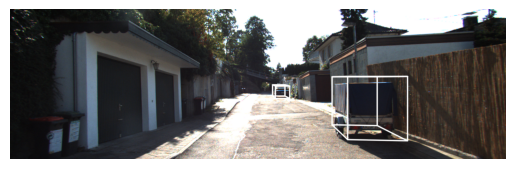

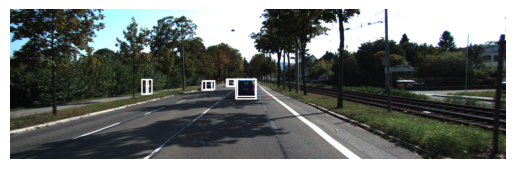

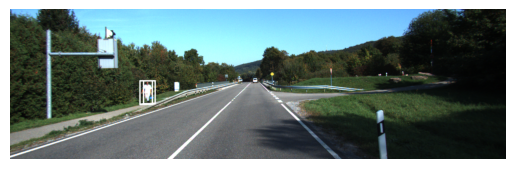

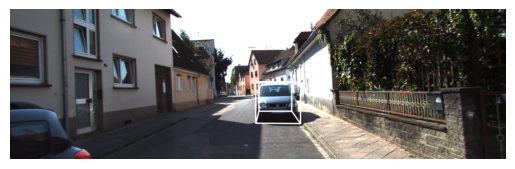

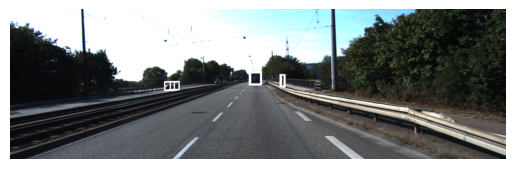

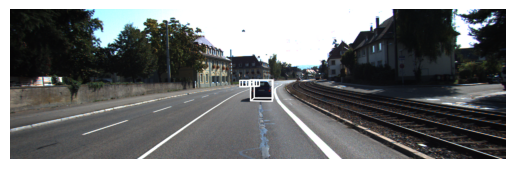

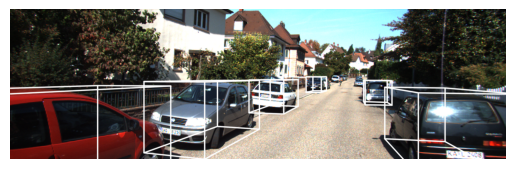

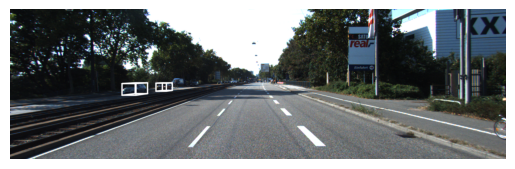

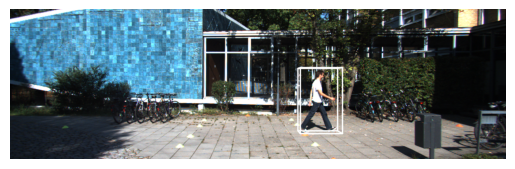

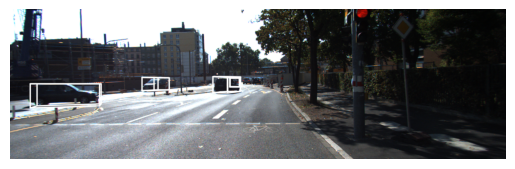

In [ ]:
# Show a grid of images from /content/frustum_pointnets_pytorch/dataset/KITTI/object/training/vis3d
import os
import matplotlib.pyplot as plt
from PIL import Image

for filename in os.listdir("/content/frustum_pointnets_pytorch/dataset/KITTI/object/training/vis3d"):
    if filename.endswith(".png"):
        image_path = os
        image = Image.open(os.path.join("/content/frustum_pointnets_pytorch/dataset/KITTI/object/training/vis3d", filename))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

